In [ ]:

import ee
import json
from datetime import datetime
from shapely.geometry import shape

try:
    from ee_ipl_uv import multitemporal_cloud_masking
    from ee_ipl_uv import image_wrapper
    print("Import ee_ipl_uv succues!")
except ImportError as e:
    print(f"Libary not found. {e}")

project_id = 'civic-athlete-496122-c4'
try:
    ee.Initialize(project=project_id)
    print("GEE initilized!")
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

Import ee_ipl_uv succues!
GEE initilized!


In [ ]:
geojson_pfad = "Landkreis_Wuerzburg.geojson" 

with open(geojson_pfad, "r", encoding="utf-8") as f:
    geojson_data = json.load(f)

if geojson_data.get("type") == "FeatureCollection":
    region_of_interest = ee.FeatureCollection(geojson_data).geometry()
else:
    region_of_interest = ee.Geometry(geojson_data)

print("succues")

succues


In [ ]:
start_date = '2025-04-01'
end_date = '2025-06-30'

landsat_collection = (ee.ImageCollection('LANDSAT/LC08/C02/T1_TOA')
                      .filterDate(start_date, end_date)
                      .filterBounds(region_of_interest))

landsat_ids = landsat_collection.aggregate_array('system:index').getInfo()
print(f"Number of Landsat photos: {len(landsat_ids)}")
if len(landsat_ids) > 0:
    print(f"Example Landsat-IDs: {landsat_ids[:3]}")

sentinel_collection = (ee.ImageCollection('COPERNICUS/S2')
                       .filterDate(start_date, end_date)
                       .filterBounds(region_of_interest))

sentinel_ids = sentinel_collection.aggregate_array('system:index').getInfo()
print(f"\n Number of Sentinel-2 photos: {len(sentinel_ids)}")
if len(sentinel_ids) > 0:
    print(f"Example Sentinel-IDs: {sentinel_ids[:3]}")

Number of Landsat photos: 21
Example Landsat-IDs: ['LC08_194025_20250412', 'LC08_194025_20250428', 'LC08_194025_20250514']


C:\Users\Linus\AppData\Roaming\Python\Python313\site-packages\ee\deprecation.py:215: DeprecationWarning: 

Attention required for COPERNICUS/S2! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by COPERNICUS/S2_HARMONIZED

Learn more: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2

  warnings.warn(warning, category=DeprecationWarning)



 Number of Sentinel-2 photos: 109
Example Sentinel-IDs: ['20250403T102559_20250403T103147_T32UNA', '20250403T102559_20250403T103147_T32UNV', '20250405T102041_20250405T102051_T32UNA']


In [4]:
# 1. ZEITREIHEN-COLLECTIONS ERSTELLEN
start_date = '2025-04-01'
end_date = '2025-06-30'

# Nutze das unbeschnittene umschließende Rechteck deiner Region
ganzes_bild_viereck = region_of_interest.bounds()

print("🔍 Starte Abfrage der Zeitreihen auf den GEE-Servern...")

# --- Landsat 8-9 Zeitreihe ---
dummy_l8_id = landsat_ids[0] if 'landsat_ids' in locals() and len(landsat_ids) > 0 else 'LC08_194026_20250415'
wrapper_l8 = image_wrapper.L8L1TImage(dummy_l8_id, collection='LANDSAT/LC08/C02/T1_TOA')

landsat_ts_collection = multitemporal_cloud_masking.ImagesWithCC(
    wrapper_img=wrapper_l8,
    start_date=start_date,
    end_date=end_date,
    region_of_interest=ganzes_bild_viereck
)

# --- Sentinel-2 Zeitreihe ---
dummy_s2_id = sentinel_ids[0] if 'sentinel_ids' in locals() and len(sentinel_ids) > 0 else '20250415T101301_20250415T101305_T32UPG'
wrapper_s2 = image_wrapper.S2L1CImage(dummy_s2_id, collection='COPERNICUS/S2')

sentinel_ts_collection = multitemporal_cloud_masking.ImagesWithCC(
    wrapper_img=wrapper_s2,
    start_date=start_date,
    end_date=end_date,
    region_of_interest=ganzes_bild_viereck
)

print(f"✅ Zeitreihen-Collections generiert!")

🔍 Starte Abfrage der Zeitreihen auf den GEE-Servern...
✅ Zeitreihen-Collections generiert!


In [5]:
# 2. METADATEN IN PANDAS-TABELLEN CONVERTIEREN
from ee_ipl_uv import converters

print("📊 Lade Zeitreihen-Metadaten herunter...")

# Landsat-Tabelle anzeigen
try:
    df_landsat = converters.eeImageCollectionToPandas(
        landsat_ts_collection, 
        properties=['system:index', 'CC', 'system:time_start']
    )
    print(f"\n📅 Landsat-Zeitreihe ({len(df_landsat)} Bilder im Zeitraum):")
    print(df_landsat[['system:index', 'CC']].to_string())
except Exception as e:
    print(f"Hinweis Landsat-Tabelle: {e}")

# Sentinel-2-Tabelle anzeigen
try:
    df_sentinel = converters.eeImageCollectionToPandas(
        sentinel_ts_collection, 
        properties=['system:index', 'CC', 'system:time_start']
    )
    print(f"\n📅 Sentinel-2-Zeitreihe ({len(df_sentinel)} Bilder im Zeitraum):")
    print(df_sentinel[['system:index', 'CC']].to_string())
except Exception as e:
    print(f"Hinweis Sentinel-Tabelle: {e}")

📊 Lade Zeitreihen-Metadaten herunter...

📅 Landsat-Zeitreihe (10 Bilder im Zeitraum):
           system:index         CC
0  LC08_195025_20250403   0.070627
1  LC08_194025_20250412   0.000000
2  LC08_195025_20250419  19.768138
3  LC08_194025_20250428   0.105366
4  LC08_194025_20250514   0.301768
5  LC08_195025_20250521   0.000000
6  LC08_194025_20250530  18.851535
7  LC08_195025_20250606   1.071006
8  LC08_194025_20250615   5.394213
9  LC08_195025_20250622   0.004454

📅 Sentinel-2-Zeitreihe (53 Bilder im Zeitraum):
                              system:index          CC
0   20250403T102559_20250403T103147_T32UNA    0.000000
1   20250405T102041_20250405T102051_T32UNA   29.493032
2   20250407T101701_20250407T101810_T32UNA    0.000000
3   20250408T103051_20250408T103158_T32UNA    1.717146
4   20250410T101559_20250410T101701_T32UNA   85.654831
5   20250410T102701_20250410T103346_T32UNA   88.178625
6   20250413T102559_20250413T102601_T32UNA   89.120057
7   20250415T102041_20250415T102719_T32U

C:\uni\Image_processing_seminar\sips\code\ee_ipl_uv-non-gee-migration\ee_ipl_uv\download.py:239: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  expr = re.compile("(%s)(-\d+-\d+)?\.%s" % (file_name, formato))


🖼️ Erzeuge visuelle Vorschau-Zeitreihe...


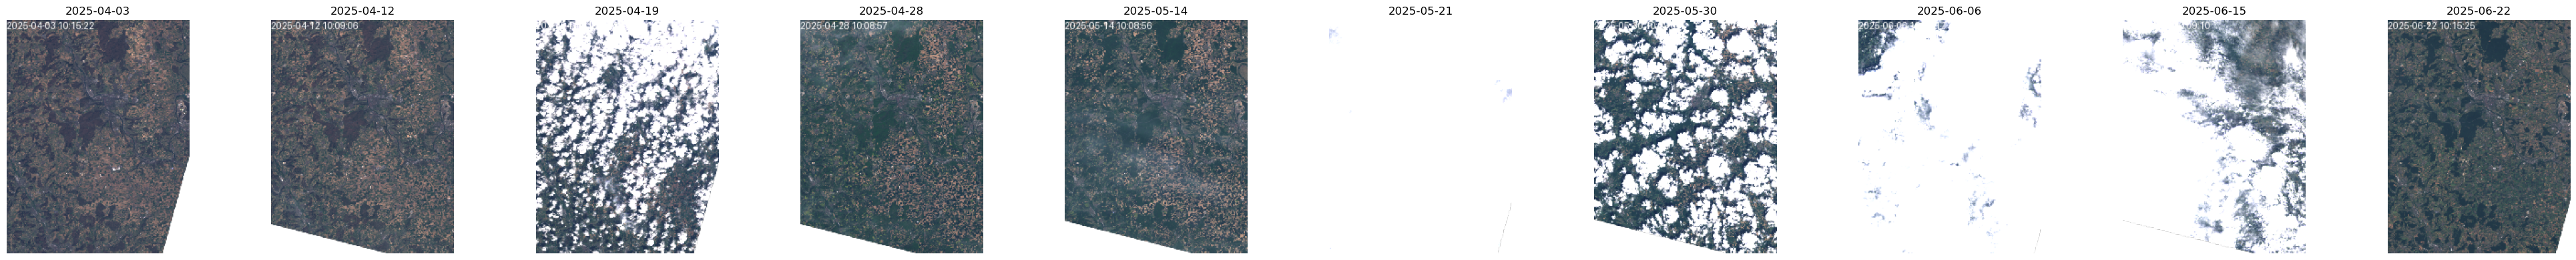

In [7]:
# 3. VISUELLE GRAPHIK DER ZEITREIHE ERZEUGEN
import matplotlib.pyplot as plt
from ee_ipl_uv import download

print("🖼️ Erzeuge visuelle Vorschau-Zeitreihe...")

thumb_params = {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0.0,
    'max': 0.3,
    'dimensions': 256,
    'format': 'png',
    'region': ganzes_bild_viereck
}

# Download der thumbs mit automatischem Zeitstempel-Footprint!
landsat_thumbs = download.DownloadImageCollectionThumb(
    img_collection=landsat_ts_collection,
    params=thumb_params,
    image_name_prepend="landsat_ts",
    add_timestamp=True
)

# Plotten der Bilder nebeneinander
num_images = len(landsat_thumbs.image_name)
if num_images > 0:
    fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4))
    if num_images == 1:
        axes = [axes]
        
    for i in range(num_images):
        img_path = landsat_thumbs.image_name[i]
        img_data = plt.imread(img_path)
        axes[i].imshow(img_data)
        axes[i].set_title(landsat_thumbs.time_start[i][:10]) # Zeigt das Datum über dem Bild
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()
else:
    print("Keine Kacheln im gewählten Zeitraum gefunden.")

In [7]:
import matplotlib.pyplot as plt
import requests
import shutil
import os
import tempfile

# Liste der Landsat IDs aus deiner Tabelle holen
landsat_id_liste = df_landsat['system:index'].tolist()

# Unsere stabilen Parameter für den Direktdownload der Trainingsdaten
custom_params = {
    "trainlocal": True,       
    "mounted_drive": False,   
    "with_task": False,       
    "sampling_factor": 0.01,  
    "lmbda": 0.1,             
    "gamma": 0.01,            
    "with_cross_validation": False,
    "n_clusters": 10
}

wuerzburg_box = region_of_interest.bounds()

def lade_thumb_als_array(url):
    tmp_file = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
    tmp_name = tmp_file.name
    
    try:
        r = requests.get(url, stream=True)
        if r.status_code == 200:
            r.raw.decode_content = True
            with tmp_file as f:
                shutil.copyfileobj(r.raw, f)
            
            img_data = plt.imread(tmp_name)
            return img_data
    except Exception as e:
        print(f"Fehler beim Laden des Thumbs: {e}")
    finally:
        if os.path.exists(tmp_name):
            os.remove(tmp_name)
            
    return None

print(f"🎬 Starte multitemporale Wolkenmaskierung mit visueller Auswertung...\n")

# Schleife über jedes Bild in deiner Zeitreihe
for i, img_id in enumerate(landsat_id_liste):
    print(f"🔄 Verarbeite Bild [{i}] -> {img_id}")
    
    try:
        # 1. Initialisiere den Wrapper für die aktuelle Kachel
        current_wrapper = image_wrapper.L8L1TImage(img_id, collection='LANDSAT/LC08/C02/T1_TOA')
        
        # Geometrie des gesamten unbeschnittenen Szenen-Vierecks holen
        ganzes_bild_viereck = current_wrapper.ee_img.geometry()
        
        # 2. ALGORITHMUS STARTEN: Berechne Maske und die Hintergrund-Vorhersage (Forecast)
        # Ändere "persistence" hier bei Bedarf zu "linear" oder "kernel"
        cloud_mask, forecast_img = multitemporal_cloud_masking.CloudClusterScore(
            img=current_wrapper, 
            region_of_interest=region_of_interest, 
            method_pred="linear", 
            params=custom_params  
        )
        
        # =========================================================================
        # ÄNDERUNG HIER: 'region' wird von 'ganzes_bild_viereck' auf 'wuerzburg_box' geändert!
        # =========================================================================
        # 3. URLs FÜR ALLE DREI ANSICHTEN GENERIEREN (Zentriert auf Würzburg)
        
        # a) Das originale Landsat-Bild (Echtfarben RGB)
        url_original = current_wrapper.ee_img.getThumbURL({
            'bands': ['B4', 'B3', 'B2'], 
            'min': 0.0, 
            'max': 0.3,
            'dimensions': 512, 
            'format': 'png', 
            'region': wuerzburg_box  # <-- HIER GEÄNDERT
        })
        
        # b) Die berechnete Wolkenmaske (Blau=Klar, Weiß=Schatten, Rot=Wolke)
        url_maske = cloud_mask.getThumbURL({
            'min': 0, 
            'max': 2, 
            'palette': 'blue,white,red',
            'dimensions': 512, 
            'format': 'png', 
            'region': wuerzburg_box  # <-- HIER GEÄNDERT
        })
        
        # c) Das wolkenfreie Hintergrundbild aus dem Forecast
        url_forecast = forecast_img.getThumbURL({
            'bands': ['B4_forecast', 'B3_forecast', 'B2_forecast'], 
            'min': 0.0, 
            'max': 0.3,
            'dimensions': 512, 
            'format': 'png', 
            'region': wuerzburg_box  # <-- HIER GEÄNDERT
        })
        
        # 4. BILDER HERUNTERLADEN UND IN MATPLOTLIB PLOTTEN (Bleibt gleich)
        img_orig_data = lade_thumb_als_array(url_original)
        img_mask_data = lade_thumb_als_array(url_maske)
        img_fore_data = lade_thumb_als_array(url_forecast)
        
        # Erstelle eine Zeile mit 3 Spalten für die Gegenüberstellung
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Spalte 1: Original
        axes[0].imshow(img_orig_data)
        axes[0].set_title(f"Original Landsat ({img_id[-8:]})")
        axes[0].axis('off')
        
        # Spalte 2: Wolkenmaske
        axes[1].imshow(img_mask_data)
        axes[1].set_title("Berechnete Wolkenmaske\n(Rot=Wolke, Weiß=Schatten, Blau=Klar)")
        axes[1].axis('off')
        
        # Spalte 3: Entfernte Wolken (Hintergrund-Rekonstruktion)
        axes[2].imshow(img_fore_data)
        axes[2].set_title("Rekonstruierter Hintergrund\n(Wolken/Schatten entfernt)")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"⚠️   Hinweis für Bild {i} ({img_id}): {e}\n")

🎬 Starte multitemporale Wolkenmaskierung mit visueller Auswertung...

🔄 Verarbeite Bild [0] -> LC08_195025_20250403
⚠️   Hinweis für Bild 0 (LC08_195025_20250403): 'normalize'

🔄 Verarbeite Bild [1] -> LC08_194025_20250412
⚠️   Hinweis für Bild 1 (LC08_194025_20250412): 'normalize'

🔄 Verarbeite Bild [2] -> LC08_195025_20250419
⚠️   Hinweis für Bild 2 (LC08_195025_20250419): 'normalize'

🔄 Verarbeite Bild [3] -> LC08_194025_20250428


KeyboardInterrupt: 

alt

In [7]:
landsat_info = landsat_collection.reduceColumns(
    ee.Reducer.toList().repeat(2), ['system:index', 'CLOUD_COVER']
).getInfo()

landsat_ids_list = landsat_info['list'][0]
cloud_percentages = landsat_info['list'][1]

print(f"{'Index':<6} | {'Landsat ID':<25} | {'offical clouds':<20}")
print("-" * 60)
for i in range(len(landsat_ids_list)):
    print(f"{i:<6} | {landsat_ids_list[i]:<25} | {cloud_percentages[i]:.2f}%")

print("-" * 70)

for i, img_id in enumerate(landsat_ids_list):
    img_temp = ee.Image(f'LANDSAT/LC08/C02/T1_TOA/{img_id}')
    
    ganzes_bild_viereck = img_temp.geometry()

    url = img_temp.getThumbURL({
        'bands': ['B4', 'B3', 'B2'],
        'min': 0.0,
        'max': 0.3,
        'dimensions': 512, 
        'format': 'png',
        'region': ganzes_bild_viereck
    })
    print(f"Index [{i}] -> {img_id} ({cloud_percentages[i]:.1f}% clouds):")
    print(f"{url}\n")

KeyboardInterrupt: 

In [ ]:
if len(landsat_ids) > 0:
    test_id_landsat = landsat_ids[8]
    print(f"Landsat-picture: {test_id_landsat}")
    
    img_wrapper_l8 = image_wrapper.L8L1TImage(test_id_landsat, collection='LANDSAT/LC08/C02/T1_TOA')
    
    # # linerar para
    # custom_params = {
    #     "trainlocal": True,       
    #     "mounted_drive": False,   
    #     "with_task": False,       
    #     "sampling_factor": 0.005,  
    #     "lmbda": 0.1,            
    #     "n_clusters": 10
    # }

    # kernel
    custom_params = {
        "trainlocal": True,       
        "mounted_drive": False,   
        "with_task": False,       
        "sampling_factor": 0.005,  
        "lmbda": 0.1,  
        "gamma": 0.01,                  
        "with_cross_validation": False,
        "n_clusters": 10
    }
    
    cloud_mask_l8, forecast_img_l8 = multitemporal_cloud_masking.CloudClusterScore(
        img_wrapper_l8, 
        region_of_interest, 
        method_pred="percentile",  #percentile,persistence,linear , kernel 
        # params=custom_params    #linear, kernel
    )

    ganzes_bild_viereck = cloud_mask_l8.geometry()
    
    mask_url_l8 = cloud_mask_l8.getThumbURL({
        'min': 0, 
        'max': 2, 
        'palette': 'blue,white,red',
        'dimensions': 1024,
        'format': 'png',
        'region': ganzes_bild_viereck
    })
    print(f"Landsat cloud-mask Link: {mask_url_l8}")
else:
    print("no picture")

Landsat-picture: LC08_194026_20250530
Landsat cloud-mask Link: https://earthengine.googleapis.com/v1/projects/civic-athlete-496122-c4/thumbnails/1206e49d727da8430e3f0a8e0b6fe019-4fd7e3e123b1756dbe0162209e3b43d8:getPixels


In [ ]:
%pip install -e C:\uni\Image_processing_seminar\sips\code\ee_ipl_uv-non-gee-migration

import ee
import json
from datetime import datetime
from shapely.geometry import shape

try:
    from ee_ipl_uv import multitemporal_cloud_masking
    from ee_ipl_uv import image_wrapper
    print("Import ee_ipl_uv succues!")
except ImportError as e:
    print(f"Libary not found. {e}")

project_id = 'civic-athlete-496122-c4'
try:
    ee.Initialize(project=project_id)
    print("GEE initilized!")
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

Obtaining file:///C:/uni/Image_processing_seminar/sips/code/ee_ipl_uv-non-gee-migration
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for ee_ipl_uv (pyproject.toml): started
  Building editable for ee_ipl_uv (pyproject.toml): finished with status 'done'
  Created wheel for ee_ipl_uv: filename=ee_ipl_uv-0.1-0.editable-py3-none-any.whl size=2792 sha256=cfa40d7236cb208e4603d39934d61ad902007fe0a1f24278dfbabca09a9913ee
  Stored in directory: C:\Users\Linus\AppData\Local\Temp\pip-ephem-wheel-cache-6ekc15qx\wheels\3a\16\72\40f39ff9

In [9]:
original_img = img_wrapper_l8.ee_img

ganzes_bild_viereck = original_img.geometry()

vorher_url = original_img.getThumbURL({
    'bands': ['B4', 'B3', 'B2'],
    'min': 0.0,
    'max': 0.3,
    'dimensions': 1024,
    'format': 'png',
    'region': ganzes_bild_viereck
})
print(f"1. Before (with clouds): \n{vorher_url}\n")

masked_img = original_img.updateMask(cloud_mask_l8.eq(0))

nachher_maskiert_url = masked_img.getThumbURL({
    'bands': ['B4', 'B3', 'B2'],
    'min': 0.0,
    'max': 0.3,
    'dimensions': 1024,
    'format': 'png',
    'region': ganzes_bild_viereck
})
print(f"2. After (found clouds): \n{nachher_maskiert_url}\n")

nachher_forecast_url = forecast_img_l8.getThumbURL({
    'bands': ['B4_forecast', 'B3_forecast', 'B2_forecast'],
    'min': 0.0,
    'max': 0.3,
    'dimensions': 1024,
    'format': 'png',
    'region': ganzes_bild_viereck
})
print(f"3. After (ground truth of model): \n{nachher_forecast_url}\n")

1. Before (with clouds): 
https://earthengine.googleapis.com/v1/projects/civic-athlete-496122-c4/thumbnails/3e76793ff4ccc7a61da69ebc4e0b5439-491c97a55ffb46ad011d5f48981e8181:getPixels

2. After (found clouds): 
https://earthengine.googleapis.com/v1/projects/civic-athlete-496122-c4/thumbnails/6c550cb3c2d23fae7b7c847af2a78389-1f62864fbb0b76a88d52bb8e2e1e6d22:getPixels

3. After (ground truth of model): 
https://earthengine.googleapis.com/v1/projects/civic-athlete-496122-c4/thumbnails/7c9dec8020e35d99d703c869abbd2fe0-2022912e9a0d3ce94a19a364f0e7b63a:getPixels



In [ ]:
sentinel_info = sentinel_collection.reduceColumns(
    ee.Reducer.toList().repeat(2), ['system:index', 'CLOUDY_PIXEL_PERCENTAGE']
).getInfo()

sentinel_ids_list = sentinel_info['list'][0]
s2_cloud_percentages = sentinel_info['list'][1]

print(f"{'Index':<6} | {'Sentinel-2 ID':<55} | {'offical clouds':<20}")
print("-" * 90)
for i in range(len(sentinel_ids_list)):
    print(f"{i:<6} | {sentinel_ids_list[i]:<55} | {s2_cloud_percentages[i]:.2f}%")

print("\n" + "="*80)
print("="*80)

for i, img_id in enumerate(sentinel_ids_list):
    img_temp = ee.Image(f'COPERNICUS/S2_HARMONIZED/{img_id}')
    
    url = img_temp.getThumbURL({
        'bands': ['B4', 'B3', 'B2'],
        'min': 0,
        'max': 3000,
        'dimensions': 512,
        'format': 'png',
        'region': region_of_interest
    })
    print(f"Index [{i}] -> {img_id} ({s2_cloud_percentages[i]:.1f}% Wolken):")
    print(f"{url}\n")
    if i == 30:
        break

Index  | Sentinel-2 Bild-ID                                      | Offizielle Bewölkung
------------------------------------------------------------------------------------------
0      | 20250403T102559_20250403T103147_T32UNA                  | 0.00%
1      | 20250403T102559_20250403T103147_T32UNV                  | 1.00%
2      | 20250405T102041_20250405T102051_T32UNA                  | 8.33%
3      | 20250405T102041_20250405T102051_T32UNV                  | 1.45%
4      | 20250407T101701_20250407T101810_T32UNA                  | 0.00%
5      | 20250407T101701_20250407T101810_T32UNV                  | 0.00%
6      | 20250408T103051_20250408T103158_T32UNA                  | 6.50%
7      | 20250408T103051_20250408T103158_T32UNV                  | 16.34%
8      | 20250410T101559_20250410T101701_T32UNA                  | 75.04%
9      | 20250410T101559_20250410T101701_T32UNV                  | 23.20%
10     | 20250410T102701_20250410T103346_T32UNA                  | 70.09%
11     | 20250

KeyboardInterrupt: 

In [ ]:
if len(sentinel_ids) > 0:
    test_id_s2 = sentinel_ids[2]
    print(f"Verarbeite Sentinel-Bild: {test_id_s2}")
    
    img_wrapper_s2 = image_wrapper.S2L1CImage(test_id_s2, collection='COPERNICUS/S2_HARMONIZED')
    
    cloud_mask_s2, forecast_img_s2 = multitemporal_cloud_masking.CloudClusterScore(
        img_wrapper_s2, 
        region_of_interest, 
        method_pred="persistence"
    )
    
    mask_url_s2 = cloud_mask_s2.getThumbURL({
        'min': 0, 
        'max': 2, 
        'palette': 'blue,white,red',
        'dimensions': 1024,
        'format': 'png',
        'region': region_of_interest
    })
    print(f"Sentinel-2 cloud-mask Link: {mask_url_s2}")
else:
    print("no picture")

Verarbeite Sentinel-Bild: 20250405T102041_20250405T102051_T32UNA
Sentinel-2 Wolkenmaske Vorschau-Link: https://earthengine.googleapis.com/v1/projects/civic-athlete-496122-c4/thumbnails/d6aa0ea36dae102c8c0d3d0affe4553f-c61123fc8a796027a3a3291543921847:getPixels


In [ ]:
original_img_s2 = img_wrapper_s2.ee_img

vorher_url_s2 = original_img_s2.getThumbURL({
    'bands': ['B4', 'B3', 'B2'],
    'min': 0.0,
    'max': 0.3,
    'dimensions': 1024,
    'format': 'png',
    'region': region_of_interest
})
print(f"1. Before (Original-Picture with clouds): \n{vorher_url_s2}\n")

masked_img_s2 = original_img_s2.updateMask(cloud_mask_s2.eq(0))

nachher_maskiert_url_s2 = masked_img_s2.getThumbURL({
    'bands': ['B4', 'B3', 'B2'],
    'min': 0.0,
    'max': 0.3,
    'dimensions': 1024,
    'format': 'png',
    'region': region_of_interest
})
print(f"2. After (found clouds): \n{nachher_maskiert_url_s2}\n")

nachher_forecast_url_s2 = forecast_img_s2.getThumbURL({
    'bands': ['B4_forecast', 'B3_forecast', 'B2_forecast'],
    'min': 0.0,
    'max': 0.3,
    'dimensions': 1024,
    'format': 'png',
    'region': region_of_interest
})
print(f"3. After (ground truth of model): \n{nachher_forecast_url_s2}\n")

1. VORHER (Original-Bild mit Wolken): 
https://earthengine.googleapis.com/v1/projects/civic-athlete-496122-c4/thumbnails/aaeb71e5b8285cf39006d49d2bcf5328-ce7980c84797a449cc04ac3ade3d59c0:getPixels

2. NACHHER (Option A - Wolken herausgeschnitten): 
https://earthengine.googleapis.com/v1/projects/civic-athlete-496122-c4/thumbnails/bfef4ab321aeb41b8b5482081b4df7f8-0241afed5df01953e7ba4272ba1d03d8:getPixels

3. NACHHER (Option B - Vom Modell geschätzter wolkenfreier Hintergrund): 
https://earthengine.googleapis.com/v1/projects/civic-athlete-496122-c4/thumbnails/4bf457968abebcbdd495bbba8c23126e-c7f6adb434c7414453510d0703c97bea:getPixels

